# Notebook 3: Predicting Claim Severity

**Goal:** given what we know about a policy and a claim, predict how much the claim will ultimately cost.
This number matters a lot to Gulf Crest: it drives pricing, reserving, and how much cash the company needs
on hand.

We will build two models and compare them:

1. A **GLM** (Generalized Linear Model), the traditional, industry-standard approach actuaries have used for
   decades. It's simple and easy to explain to a regulator or a manager.
2. A **gradient boosting model**, a more modern machine learning approach that can pick up complex patterns
   automatically, often at the cost of being harder to explain.

The point of this notebook isn't "which model wins." It's understanding the real trade-off actuaries face
today: accuracy versus explainability. Both matter, and the right choice depends on the situation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import GammaRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 20)

DATA_DIR = "../04_Datasets/"
policies = pd.read_csv(DATA_DIR + "01_policies.csv")
claims   = pd.read_csv(DATA_DIR + "02_claims.csv")

print("Data loaded.")

Data loaded.


## Step 1: Preparing the Data

Before any model can learn from our data, we need to put it in a shape the model understands. This step is
usually called **feature engineering**, deciding which pieces of information (features) the model should
look at, and getting them into a numeric, model-friendly format.

A few things we need to handle:

- **Join claims to policies.** A claim by itself doesn't tell us much about the property. We need policy
  details like insured value and construction type, joined in through `policy_id`.
- **Missing values.** Recall from Notebook 2 that 17 claims are missing a `cause_of_loss` because they were
  reported very recently and have not yet been fully classified. These rows cannot simply be dropped (doing so would
  throw away real, valid claims), so we'll fill the gap with a placeholder category, `"Unknown"`, rather
  than guessing at a real cause.
- **Categorical variables.** Columns like `construction_type` or `coverage_type` are text categories, not
  numbers. Models need numbers, so we convert each category into a set of 0/1 columns, a standard technique
  called **one-hot encoding**. For example, `coverage_type` becomes two columns, `coverage_type_Homeowners`
  and `coverage_type_Commercial`, each either 0 or 1.
- **Scaling numeric features.** `total_insured_value` is a big number (often in the hundreds of thousands),
  while the one-hot columns are only 0 or 1. Some models (including the GLM built below) fit much
  better when numeric columns are put on a similar scale first, a step called **standardization** (rescaling
  a column so it has a mean of 0 and a consistent spread). This doesn't change what the data means, only the
  units it's measured in internally.

In [2]:
# Join claims to their policy details
data = claims.merge(
    policies[["policy_id", "total_insured_value", "coastal_zone_flag", "construction_type",
              "coverage_type", "year_built"]],
    on="policy_id", how="left"
)

# Fill the missing cause_of_loss with an explicit placeholder rather than guessing
data["cause_of_loss"] = data["cause_of_loss"].fillna("Unknown")

# A simple derived feature: how old is the property? Older properties may be more
# vulnerable to damage. This is the kind of thing actuaries call a "feature" -
# a piece of information we hand to the model, sometimes calculated rather than
# taken directly from a raw column.
data["property_age"] = 2026 - data["year_built"]

# The columns we'll feed into our models
numeric_features = ["total_insured_value", "property_age"]
categorical_features = ["coastal_zone_flag", "construction_type", "coverage_type",
                          "cause_of_loss", "is_catastrophe_flag"]

target = "reported_severity"

model_data = data[numeric_features + categorical_features + [target]].copy()
print(f"Rows available for modeling: {len(model_data)}")
model_data.head()

Rows available for modeling: 2883


,total_insured_value,property_age,coastal_zone_flag,construction_type,coverage_type,cause_of_loss,is_catastrophe_flag,reported_severity
0,157200.0,33,N,Frame,Homeowners,Fire,N,8689.85
1,256600.0,29,N,Frame,Homeowners,Vandalism,N,858.40
2,331300.0,18,N,Masonry Veneer,Homeowners,Liability,N,10464.68
3,620100.0,50,Y,Masonry,Commercial,Fire,N,25062.11
4,459800.0,51,Y,Frame,Homeowners,Liability,N,13536.78


## Step 2: Splitting Into Training and Test Sets

We never evaluate a model on the same data it learned from, that would be like grading a student on the
exact questions they were given the answers to beforehand. Instead, we split the data:

- **Training set** (80% of rows): the model learns patterns from this.
- **Test set** (20% of rows, held back): we check how well the model performs on data it has never seen.
  This is our honest estimate of how the model will do on brand-new claims in the future.

In [3]:
X = model_data[numeric_features + categorical_features]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 2306
Test rows: 577


## Step 3: Model 1, the GLM (Gamma Regression)

Recall from Notebook 2 that claim severity is right-skewed: mostly modest amounts, with a long tail of
large claims. A plain linear regression assumes errors are symmetric and can even predict negative dollar
amounts, which makes no sense for a claim cost.

A **Gamma GLM** is built specifically for this kind of positive, right-skewed data. It's the standard
actuarial approach (this is one of the model families tested on the CAS's own predictive analytics exam),
and its predictions come out as an easy-to-read multiplicative formula: each feature scales the prediction
up or down by a certain factor, which is straightforward to explain to a manager or regulator.

This is built using a scikit-learn `Pipeline`, which chains together the preprocessing (one-hot
encoding) and the model itself into one object, so we can call `.fit()` and `.predict()` once instead of
doing every step by hand.

In [4]:
# ColumnTransformer applies different preprocessing to different columns:
# - categorical columns get one-hot encoded
# - numeric columns get standardized (put on a comparable scale), which the GLM's
#   solver needs to fit properly when a feature like total_insured_value is a large number
glm_preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

glm_pipeline = Pipeline(steps=[
    ("preprocess", glm_preprocessor),
    ("model", GammaRegressor(alpha=0.01, max_iter=2000))
])

glm_pipeline.fit(X_train, y_train)
glm_predictions = glm_pipeline.predict(X_test)

print("GLM training complete.")

GLM training complete.


## Step 4: Model 2, Gradient Boosting

A **gradient boosting model** builds many small decision trees one after another, where each new tree
focuses on correcting the mistakes of the ones before it. It can automatically find complex, non-linear
patterns and interactions between features that a GLM would need those patterns spelled out manually to
catch.

We're using `HistGradientBoostingRegressor` with a `gamma` loss function, which keeps it aligned with the
same right-skewed, positive-only nature of claim severity that motivated the GLM choice above. This isn't a
completely different modeling philosophy, it's the same target distribution assumption, matched with a more
flexible, harder-to-interpret model.

In [5]:
# Tree-based models like gradient boosting don't need numeric scaling the way the
# GLM did (a tree only asks "is this value above or below a threshold?", so the
# units don't matter). We still one-hot encode the categories so both models see
# exactly the same underlying information, keeping the comparison fair.
gbm_preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
], remainder="passthrough")

gbm_pipeline = Pipeline(steps=[
    ("preprocess", gbm_preprocessor),
    ("model", HistGradientBoostingRegressor(loss="gamma", max_iter=200, random_state=42))
])

gbm_pipeline.fit(X_train, y_train)
gbm_predictions = gbm_pipeline.predict(X_test)

print("Gradient boosting training complete.")

Gradient boosting training complete.


## Step 5: Comparing the Two Models

We'll use two error metrics that are easier to read than raw statistical jargon:

- **Mean Absolute Error (MAE):** on average, how far off is a prediction from the actual claim amount, in
  dollars? Lower is better.
- **R-squared (R2):** roughly, what fraction of the variation in claim severity does the model explain?
  Ranges from 0 (no better than guessing the average every time) to 1 (perfect prediction). Higher is
  better, though 1.0 is unrealistic for messy real-world data like this.

In [6]:
results = pd.DataFrame({
    "Model": ["GLM (Gamma)", "Gradient Boosting"],
    "MAE ($)": [
        mean_absolute_error(y_test, glm_predictions),
        mean_absolute_error(y_test, gbm_predictions)
    ],
    "R2": [
        r2_score(y_test, glm_predictions),
        r2_score(y_test, gbm_predictions)
    ]
})
results["MAE ($)"] = results["MAE ($)"].round(0)
results["R2"] = results["R2"].round(3)
print(results.to_string(index=False))

            Model  MAE ($)    R2
      GLM (Gamma)  39615.0 0.288
Gradient Boosting  37500.0 0.334


If gradient boosting scores better on both metrics, that matches the general finding in the research
literature: more flexible models tend to predict claim costs more accurately. "More accurate" is not the
same as "better for every purpose," which the next section addresses directly.

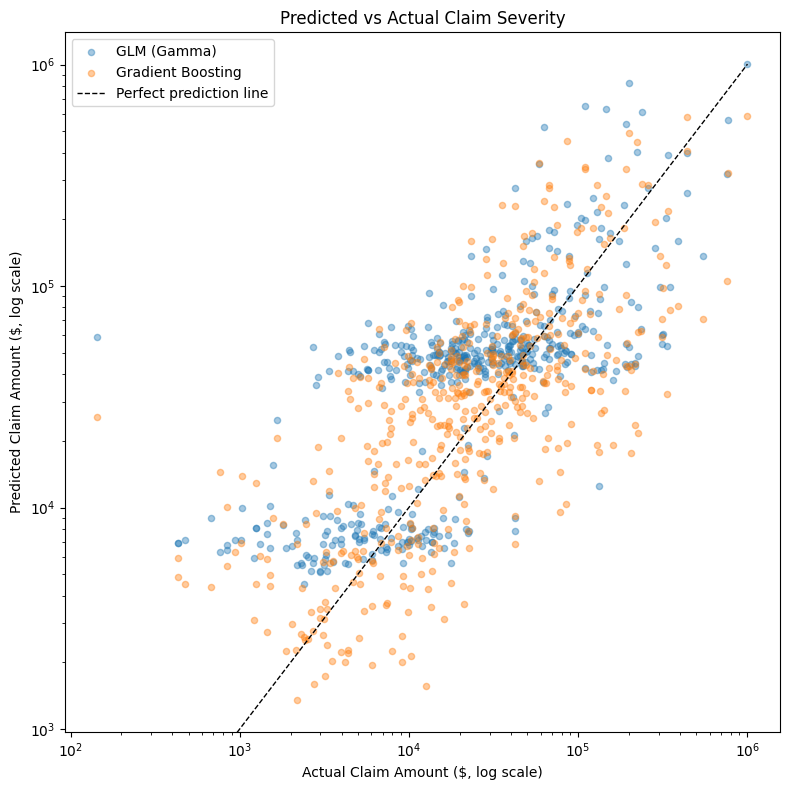

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
sample = np.random.choice(len(y_test), size=min(500, len(y_test)), replace=False)

ax.scatter(y_test.values[sample], glm_predictions[sample], alpha=0.4, label="GLM (Gamma)", s=20)
ax.scatter(y_test.values[sample], gbm_predictions[sample], alpha=0.4, label="Gradient Boosting", s=20)

max_val = max(y_test.max(), glm_predictions.max(), gbm_predictions.max())
ax.plot([0, max_val], [0, max_val], "k--", linewidth=1, label="Perfect prediction line")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual Claim Amount ($, log scale)")
ax.set_ylabel("Predicted Claim Amount ($, log scale)")
ax.set_title("Predicted vs Actual Claim Severity")
ax.legend()
plt.tight_layout()
plt.savefig("outputs_prediction_comparison.png", dpi=120)
plt.show()

Points sitting exactly on the dashed diagonal line would mean perfect predictions. In practice, both
models scatter around it, some overpredicting, some underpredicting, which is completely normal for this
kind of data. What you're looking for is whether one model's points cluster more tightly around that line
than the other's, especially for the very large claims on the upper right, since those are the ones that
matter most financially.

## Step 6: Why the GLM Is Still Worth Knowing (Interpretability)

One major advantage of the GLM is that we can look directly at what it learned. Each coefficient tells us,
in plain terms, how much a feature multiplies the predicted claim amount by. Gradient boosting has no
equivalent simple table. Its logic is spread across hundreds of small decision trees, which makes it far
harder to explain to a regulator, a manager, or a policyholder asking why their claim was priced the way it
was.

In [8]:
# Pull out the trained GLM's coefficients and the names of the encoded features
encoded_feature_names = glm_pipeline.named_steps["preprocess"].get_feature_names_out()
glm_coefficients = glm_pipeline.named_steps["model"].coef_

coef_table = pd.DataFrame({
    "feature": encoded_feature_names,
    "coefficient": glm_coefficients
}).sort_values("coefficient", ascending=False)

print("How each feature scales the predicted claim amount (higher = larger effect):")
print(coef_table.to_string(index=False))

How each feature scales the predicted claim amount (higher = larger effect):
                                              feature  coefficient
                           cat__is_catastrophe_flag_Y     0.781530
                             num__total_insured_value     0.519925
                      cat__cause_of_loss_Wind + Flood     0.256998
                              cat__cause_of_loss_Wind     0.241657
                        cat__coverage_type_Commercial     0.229241
                 cat__cause_of_loss_Flood/Storm Surge     0.176939
cat__construction_type_Superior (Reinforced Concrete)     0.127289
                           cat__cause_of_loss_Unknown     0.105936
                 cat__cause_of_loss_Frozen Pipe Burst     0.022950
                             cat__coastal_zone_flag_Y     0.011755
                       cat__construction_type_Masonry     0.007874
          cat__cause_of_loss_Water Damage (Non-Storm)    -0.000814
                  cat__cause_of_loss_Lightning Strik

Because this is a Gamma GLM with a log link (the standard setup), each coefficient works
multiplicatively rather than additively: a positive coefficient means that feature scales the predicted
claim amount up, a negative one scales it down. Each categorical row above (for example,
`is_catastrophe_flag`, or a particular `construction_type`) can be stated as a one-sentence effect on the
prediction; doing this for the top three or four rows is good practice for interpreting a GLM in a real
setting.

One note on `total_insured_value` and `property_age`: since we standardized these before fitting (Step 1),
their coefficients describe the effect of a one-standard-deviation change, not a one-dollar or one-year
change. The categorical coefficients above aren't affected by this and can be read directly.

## Summary

1. Claim severity needs a model built for positive, right-skewed data, not plain linear regression. Both
   models here were chosen with that in mind.
2. A GLM gives up some predictive accuracy in exchange for a result that's simple to explain, an important
   trade-off in a regulated industry where you may need to justify a pricing or reserving decision.
3. Gradient boosting can capture more complex patterns and often predicts more accurately, but its internal
   logic is much harder to communicate.
4. Neither model is universally "correct." Which one an actuary uses in practice depends on the purpose: an
   official rate filing leans toward the GLM's transparency, while an internal triage or flagging tool has
   more room for a less transparent but more accurate model.

**Next:** Open `04_Fraud_Detection.ipynb` to flag claims that may be fraudulent, and see how the class
imbalance we noticed in Notebook 2 (only ~15% of investigated claims are flagged as fraud) needs to be
handled carefully.